# 数据整合
将数据整合成以下格式：

**目标格式（必需列）：**
- `stockid` — 股票代码
- `date` — 交易日期
- `eventdate` — 事件日期
- `sreturn` — 个股收益率
- `mreturn` — 市场收益率

P.S. 如果事件日处于停牌期间，则跳过对事件的计算。停牌或由上市公司主动申请，或由证监会强制执行，理由是发生重大事项，如资产重组、控制权变更等，这会扰乱异常收益率的计算。
est_window=(-210, -10)（左闭右开）意味着从事件日前第210天至第11天，即200天的估计窗口

In [1]:
import pandas as pd
import sqlite3
from pathlib import Path
import os
import warnings
warnings.filterwarnings('ignore')
# 获取当前工作目录
BASE_DIR = Path.cwd()
print(f'当前代码的工作路径是：{BASE_DIR}')

当前代码的工作路径是：f:\BaiduSyncdisk\Event study calculator\event_study-0.1.4


## 从 SQLite 读取个股日收益率

In [62]:
'''
print("正在读取个股收益率数据...")
DB_PATH = r"公司数据集\日个股回报率数据 19950101-20260416\stock_daily_data\stock_daily_data.db"
conn = sqlite3.connect(DB_PATH)
stock_df = pd.read_sql_query(
    "SELECT Stkcd, Trddt, Dretnd FROM daily_data ORDER BY Stkcd, Trddt",
    conn
)
conn.close()

stock_df.columns = ['stockid', 'date', 'sreturn']
stock_df['date'] = pd.to_datetime(stock_df['date'])
print(f"个股数据: {len(stock_df)} 条记录, {stock_df['stockid'].nunique()} 只股票")
print(f"数据范围: {stock_df['date'].min().date()} ~ {stock_df['date'].max().date()}")
'''

'\nprint("正在读取个股收益率数据...")\nDB_PATH = r"公司数据集\\日个股回报率数据 19950101-20260416\\stock_daily_data\\stock_daily_data.db"\nconn = sqlite3.connect(DB_PATH)\nstock_df = pd.read_sql_query(\n    "SELECT Stkcd, Trddt, Dretnd FROM daily_data ORDER BY Stkcd, Trddt",\n    conn\n)\nconn.close()\n\nstock_df.columns = [\'stockid\', \'date\', \'sreturn\']\nstock_df[\'date\'] = pd.to_datetime(stock_df[\'date\'])\nprint(f"个股数据: {len(stock_df)} 条记录, {stock_df[\'stockid\'].nunique()} 只股票")\nprint(f"数据范围: {stock_df[\'date\'].min().date()} ~ {stock_df[\'date\'].max().date()}")\n'

# 从CSV读取个股日收益率

In [63]:
DB_PATH = r"公司数据集\日个股回报率数据 19950101-20260416\中石油中石化中海油_日个股回报率文件 2023-01-01 至 2026-04-20\TRD_Dalyr.csv"
stock_df = pd.read_csv(DB_PATH,usecols=['Stkcd','Trddt','Dretnd'], dtype={'Stkcd':str}) #Dretwd：[考虑现金红利再投资的日个股回报率]，Dretnd： [不考虑现金红利的日个股回报率] 
stock_df.columns = ['stockid', 'date', 'sreturn']
stock_df['date'] = pd.to_datetime(stock_df['date'])
print(f"个股数据: {len(stock_df)} 条记录, {stock_df['stockid'].nunique()} 只股票")
print(f"数据范围: {stock_df['date'].min().date()} ~ {stock_df['date'].max().date()}")

个股数据: 2388 条记录, 3 只股票
数据范围: 2023-01-03 ~ 2026-04-20


In [64]:
stock_df

,stockid,date,sreturn
0,600028,2023-01-03,0.009174
1,600028,2023-01-04,0.002273
2,600028,2023-01-05,-0.004535
3,600028,2023-01-06,-0.002278
4,600028,2023-01-09,0.000000
...,...,...,...
2383,601857,2026-04-14,-0.013234
2384,601857,2026-04-15,-0.014250
2385,601857,2026-04-16,-0.009354
2386,601857,2026-04-17,-0.010300


## 读取市场指数数据

主要指数的开始日期（发布日）如下：

| 代码 | 指数名称 | 开始日期 (发布日) | 基日 | 代号|
| :--- | :--- | :--- | :--- | :--- |
| **1** | 上证综合指数 | **1991-07-15** | 1990-12-19 |SH_ZH|
| **2** | 上证综合A股指数 | **1992-02** (约) | 1990-12-19 |SH_ZH_A|
| **3** | 上证综合B股指数 | **1992-02** (约) | 1992-02-21 |SH_ZH_B|
| **399106** | 深证综合指数 | **1991-04-04** | 1991-04-03 |SZ_ZH|
| **399107** | 深证综合A股指数 | **1992-10-04** | 1991-04-03 |SZ_ZH_A|
| **399108** | 深证综合B股指数 | **1992-10-06** | 1992-02-28 |SZ_ZH_B|
| **399001** | 深证成份指数 | **1995-01-23** (发布)<br>**1995-05-05** (启用) | 1994-07-20 |SZ_CF|
| **300** | 沪深300 | **2005-04-08** | 2004-12-31 |HS_300|

In [65]:
print("\n正在读取市场指数数据...")
IDX_FILE = r"公司数据集\指数文件 19901219-20260416\TRD_Index.csv"
MARKET_INDEX_CODE = 'HS_300' #选取沪深300作为指数
print(f'选择{MARKET_INDEX_CODE}作为市场指数')
index_name_mapping = {
    1: 'SH_ZH', #上证综合指数
    2: 'SH_ZH_A', #上证综合A股指数
    3: 'SH_ZH_B', #上证综合B股指数
    399106: 'SZ_ZH', #深证综合指数
    399107: 'SZ_ZH_A', #深证综合A股指数
    399108: 'SZ_ZH_B', #深证综合B股指数
    399001: 'SZ_CF', #深证成份指数
    10: 'SH_180', #上证180
    399004: 'SZ_100', #深证100
    300: 'HS_300', #沪深300
    902: 'ZZ_LT', #中证流通
    903: 'ZZ_100', #中证100
    399903: 'ZZ_100_SZ', #中证100 深圳
    399329: 'ZXBZ', #中小板指 深圳
    20: 'SH_MC' #上证中型企业综合指数
}
idx_raw = pd.read_csv(IDX_FILE, dtype={'Indexcd': int})
idx_raw['Index_Mapping'] = idx_raw['Indexcd'].map(index_name_mapping)
idx_filtered = idx_raw[idx_raw['Index_Mapping'] == MARKET_INDEX_CODE].copy()
idx_filtered['date'] = pd.to_datetime(idx_filtered['Trddt'])
idx_filtered = idx_filtered[['date', 'Retindex']].rename(columns={'Retindex': 'mreturn'})
idx_filtered = idx_filtered.set_index('date').sort_index()
idx_filtered = idx_filtered[idx_filtered.index >= stock_df['date'].min()]
print(f"市场指数数据: {len(idx_filtered)} 条记录")
print(f"{MARKET_INDEX_CODE}的指数日期范围: {idx_filtered.index.min().date()} ~ {idx_filtered.index.max().date()}")


正在读取市场指数数据...
选择HS_300作为市场指数


市场指数数据: 794 条记录
HS_300的指数日期范围: 2023-01-03 ~ 2026-04-16


In [66]:
idx_filtered

,mreturn
date,
2023-01-03,0.004201
2023-01-04,0.001299
2023-01-05,0.019427
2023-01-06,0.003102
2023-01-09,0.008096
...,...
2026-04-10,0.015405
2026-04-13,0.002068
2026-04-14,0.011866


## 读取事件数据表

In [67]:
EVENT_FILE = r"公司数据集\事件日数据表"

In [68]:
import pandas as pd
# 中国石油：601857 # 中国石化：600028 # 中国海油：600938
data = {
    "stockid": ["601857", "600028", "600938"],
    "eventdate": ["2026-02-28"] * 3
}

df = pd.DataFrame(data)

# 转换为 datetime
df["eventdate"] = pd.to_datetime(df["eventdate"], format="%Y-%m-%d")

# 导出
df.to_csv(EVENT_FILE + r"\event_info.csv", index=False)

df

,stockid,eventdate
0,601857,2026-02-28
1,600028,2026-02-28
2,600938,2026-02-28


In [69]:
print("\n正在读取事件列表...")
events_raw = pd.read_csv(EVENT_FILE+'\event_info.csv')
print(f"原始事件数: {len(events_raw)}")
# print(events_raw.head())

# 转换事件日期
# 先去除时间部分，只保留日期
events_raw['eventdate'] = events_raw['eventdate'].str.split(' ').str[0]
events_raw['eventdate'] = pd.to_datetime(events_raw['eventdate'], format='%Y-%m-%d')
# del events_raw['event_date_clean']
events_raw['stockid'] = events_raw['stockid'].astype(str).str.zfill(6) #统一补齐到6位数的公司代码
events = events_raw.copy()
print(f"\n处理后事件数: {len(events)}")
print(events)


正在读取事件列表...
原始事件数: 3

处理后事件数: 3
  stockid  eventdate
0  601857 2026-02-28
1  600028 2026-02-28
2  600938 2026-02-28


## 合并数据

In [70]:
# ============================================================
# 4. 合并数据
# ============================================================
print("\n正在合并数据...")

# 合并个股收益率和市场收益率
merged = pd.merge(stock_df, idx_filtered.reset_index(), on='date', how='inner')
print(f"合并后记录数: {len(merged)}")

# 合并事件信息
df_eventstudy = pd.merge(merged, events, on='stockid', how='inner')
print(f"与事件合并后记录数: {len(df_eventstudy)}")

# 整理列顺序
df_eventstudy = df_eventstudy[['stockid', 'date', 'eventdate', 'sreturn', 'mreturn']]
df_eventstudy = df_eventstudy.sort_values(['stockid','eventdate','date'])
print("\n最终数据预览:")
print(df_eventstudy.head(10))
print(f"\n数据形状: {df_eventstudy.shape}")
print(f"股票数量: {df_eventstudy['stockid'].nunique()}")
print(f"事件数量: {df_eventstudy['eventdate'].nunique()}")


正在合并数据...
合并后记录数: 2382
与事件合并后记录数: 2382

最终数据预览:
  stockid       date  eventdate   sreturn   mreturn
0  600028 2023-01-03 2026-02-28  0.009174  0.004201
1  600028 2023-01-04 2026-02-28  0.002273  0.001299
2  600028 2023-01-05 2026-02-28 -0.004535  0.019427
3  600028 2023-01-06 2026-02-28 -0.002278  0.003102
4  600028 2023-01-09 2026-02-28  0.000000  0.008096
5  600028 2023-01-10 2026-02-28 -0.002283  0.001085
6  600028 2023-01-11 2026-02-28  0.009153 -0.001853
7  600028 2023-01-12 2026-02-28  0.006803  0.001955
8  600028 2023-01-13 2026-02-28  0.002252  0.014064
9  600028 2023-01-16 2026-02-28  0.004494  0.015607

数据形状: (2382, 5)
股票数量: 3
事件数量: 1


In [71]:
output_path =r"output\tables\df_eventstudy.csv"
df_eventstudy.to_csv(output_path, index=False)
print(f"\n数据已保存至: {output_path}")


数据已保存至: output\tables\df_eventstudy.csv


# 事件期间的异常收益率计算

In [72]:
import sys
import pandas as pd
import os
import warnings
from pathlib import Path
warnings.filterwarnings("ignore")
from event_study import event_study

# 获取当前工作目录
BASE_DIR = Path.cwd().parent
df_eventstudy = pd.read_csv(r"output\tables\df_eventstudy.csv")
suspension_file = r"公司数据集\交易停复牌数据表 1997-03-03 至 2026-04-01\TSR_Stkstat.csv"

t_test_df, df_ar_by_company, df_aar, df_exclusion = event_study(
    df_eventstudy=df_eventstudy,
    event_window_list=[(-2, 10), (-3, 3)],
    est_window=(-210, -10),
    predict_model='market',
    suspension_file=suspension_file,
    print_event_details=True,
    min_est_days=240, #过滤掉事件日前一年的交易日数量不足240天的记录
    check_stockid='601857',
    save_path='output/tables'
)

停牌过滤: 没有需要移除的记录
{'Total Events in Original Data': 3, 'Events with Insufficient Data': 0, 'Total Events in Cleaned Data': 3}
每个公司在事件窗口期内的AR已保存: output/tables\market_model_AR_by_company.csv
所有公司每天的平均AR (AAR) 已保存: output/tables\market_model_AAR_daily.csv
The file has been saved to: output/tables\market_model_ttest.xlsx
异常记录: 没有需要排除的记录

打印每个公司每个事件日前后 10 天的数据

>>> 检查股票 601857 的原始事件数据 <<<
原始事件数: 1
  - 601857 | 2026-02-28 [已保留]


--- 公司 601857 | 事件日 2026-02-28 ---
stockid       date  eventdate   sreturn   mreturn   date1
 601857 2026-02-24 2026-02-28  0.052182  0.010115 -4 days
 601857 2026-02-25 2026-02-28 -0.009017  0.006021 -3 days
 601857 2026-02-26 2026-02-28 -0.009099 -0.001903 -2 days
 601857 2026-02-27 2026-02-28 -0.002755 -0.003433 -1 days
 601857 2026-03-02 2026-02-28  0.100368  0.003826  2 days
 601857 2026-03-03 2026-02-28  0.100418 -0.015390  3 days
 601857 2026-03-04 2026-02-28  0.006844 -0.011442  4 days
 601857 2026-03-05 2026-02-28 -0.041541  0.009792  5 days
 601857 2026-03-

In [73]:
print("\n=== 异常记录 ===")
df_exclusion


=== 异常记录 ===


""


In [74]:
print("\n=== 事件研究结果 ===")
df_ar_by_company


=== 事件研究结果 ===


,stockid,event_window_str,date,eventdate,relative_day_raw,relative_day_adj,est_window_start,est_window_end,est_window_length,event_window_start,event_window_end,event_window_length,AR,var_AR,df,Std. E. AR,CAR,Std. E. CAR,CAR_T-stat,CAR_P-value
0,600028,"[-2,10]",2026-02-26,2026-02-28,-2,-2,2025-08-02,2026-02-18,200,2026-02-26,2026-03-10,13,-0.004907,0.000147,198.0,0.012114,-0.004907,0.012114,-0.405052,6.858763e-01
1,600028,"[-2,10]",2026-02-27,2026-02-28,-1,-1,2025-08-02,2026-02-18,200,2026-02-26,2026-03-10,13,-0.004730,0.000147,198.0,0.012114,-0.009637,0.017132,-0.562492,5.744173e-01
2,600028,"[-2,10]",2026-03-02,2026-02-28,2,0,2025-08-02,2026-02-18,200,2026-02-26,2026-03-10,13,0.099571,0.000147,198.0,0.012114,0.089935,0.020982,4.286248,2.835682e-05
3,600028,"[-2,10]",2026-03-03,2026-02-28,3,1,2025-08-02,2026-02-18,200,2026-02-26,2026-03-10,13,0.101300,0.000147,198.0,0.012114,0.191234,0.024228,7.893077,1.971756e-13
4,600028,"[-2,10]",2026-03-04,2026-02-28,4,2,2025-08-02,2026-02-18,200,2026-02-26,2026-03-10,13,-0.052779,0.000147,198.0,0.012114,0.138456,0.027088,5.111360,7.511887e-07
5,600028,"[-2,10]",2026-03-05,2026-02-28,5,3,2025-08-02,2026-02-18,200,2026-02-26,2026-03-10,13,-0.051820,0.000147,198.0,0.012114,0.086636,0.029673,2.919651,3.910335e-03
6,600028,"[-2,10]",2026-03-06,2026-02-28,6,4,2025-08-02,2026-02-18,200,2026-02-26,2026-03-10,13,-0.022244,0.000147,198.0,0.012114,0.064391,0.032051,2.009034,4.589162e-02
7,600028,"[-2,10]",2026-03-09,2026-02-28,9,5,2025-08-02,2026-02-18,200,2026-02-26,2026-03-10,13,0.018140,0.000147,198.0,0.012114,0.082531,0.034264,2.408690,1.692606e-02
8,600028,"[-2,10]",2026-03-10,2026-02-28,10,6,2025-08-02,2026-02-18,200,2026-02-26,2026-03-10,13,-0.065073,0.000147,198.0,0.012114,0.017458,0.036342,0.480372,6.314933e-01
9,600028,"[-2,10]",2026-03-11,2026-02-28,11,7,2025-08-02,2026-02-18,200,2026-02-26,2026-03-10,13,-0.008998,0.000147,198.0,0.012114,0.008460,0.038308,0.220833,8.254499e-01


In [75]:
df_aar

,event_window_str,relative_day_adj,AAR,Std. E. AAR,AAR_T-stat,AAR_P-value,Median_AR,Wilcoxon_Z_Median_AR,Wilcoxon_Z_Median_AR_P-value,Positive_AR(%),...,Wilcoxon_Z_Median_CAR_P-value,Positive_CAR(%),Negative_CAR(%),Sign_Z_Positive_CAR,Sign_Z_Positive_CAR_P-value,CAAR,Std. E. CAAR,CAAR_T-stat,CAAR_P-value,N_Events
0,"[-2,10]",-2,-0.013553,0.008116,-1.669899,9.546628e-02,-0.010198,-1.603567,0.108809,0.000000,...,0.108809,0.000000,100.000000,-1.732051,0.083265,-0.013553,0.008116,-1.669899,9.546628e-02,3
1,"[-2,10]",-1,0.001133,0.008116,0.139546,8.890660e-01,-0.003582,0.000000,1.000000,33.333333,...,0.108809,0.000000,100.000000,-1.732051,0.083265,-0.012421,0.011478,-1.082123,2.794176e-01,3
2,"[-2,10]",0,0.098330,0.008116,12.115097,0.000000e+00,0.098251,-1.603567,0.108809,100.000000,...,0.108809,100.000000,0.000000,1.732051,0.083265,0.085909,0.014058,6.111105,1.212407e-09,3
3,"[-2,10]",1,0.103022,0.008116,12.693229,0.000000e+00,0.101715,-1.603567,0.108809,100.000000,...,0.108809,100.000000,0.000000,1.732051,0.083265,0.188931,0.016233,11.638987,0.000000e+00,3
4,"[-2,10]",2,-0.018037,0.008116,-2.222289,2.663966e-02,-0.008771,-1.069045,0.285049,33.333333,...,0.108809,100.000000,0.000000,1.732051,0.083265,0.170894,0.018149,9.416389,0.000000e+00,3
5,"[-2,10]",3,-0.043793,0.008116,-5.395736,9.870869e-08,-0.044718,-1.603567,0.108809,0.000000,...,0.108809,100.000000,0.000000,1.732051,0.083265,0.127101,0.019881,6.393147,1.835796e-10,3
6,"[-2,10]",4,-0.028001,0.008116,-3.449939,6.004746e-04,-0.029100,-1.603567,0.108809,0.000000,...,0.108809,100.000000,0.000000,1.732051,0.083265,0.099100,0.021474,4.614950,4.050388e-06,3
7,"[-2,10]",5,0.047670,0.008116,5.873318,7.114325e-09,0.050684,-1.603567,0.108809,100.000000,...,0.108809,100.000000,0.000000,1.732051,0.083265,0.146770,0.022956,6.393422,1.777811e-10,3
8,"[-2,10]",6,-0.067581,0.008116,-8.326583,4.440892e-16,-0.065073,-1.603567,0.108809,0.000000,...,0.108809,100.000000,0.000000,1.732051,0.083265,0.079189,0.024349,3.252249,1.152065e-03,3
9,"[-2,10]",7,0.005019,0.008116,0.618390,5.365554e-01,0.009109,-1.069045,0.285049,66.666667,...,0.108809,100.000000,0.000000,1.732051,0.083265,0.084208,0.025666,3.280906,1.040712e-03,3


# 绘图

## 指定具体公司、事件日、事件窗口

Figure saved to: output\graphs\601857_2026-02-28.png


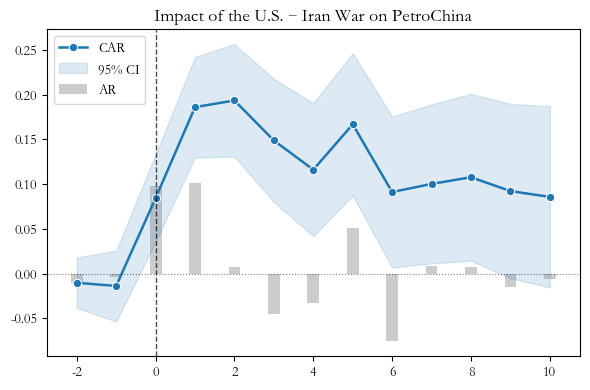

In [9]:
import pandas as pd
from event_study import  plot_company_event
e_id = '601857'
e_date = '2026-02-28'
df_ar_by_company = pd.read_csv(r'output/tables/market_model_AR_by_company.csv')

plot_company_event(
    df_ar_by_company,
    figsize=(6,4),
    stockid=str(e_id),
    eventdate=pd.to_datetime(e_date, format='%Y-%m-%d'),  # 替换成实际事件日
    event_window='[-2,10]',
    title='Impact of the U.S.–Iran War on PetroChina',
    show_ci=True,
    save_path=rf'output\graphs\{e_id}_{e_date}.png',
    xlabel='',
    ylabel=''
)

Figure saved to: output\graphs\600028_2026-02-28.png


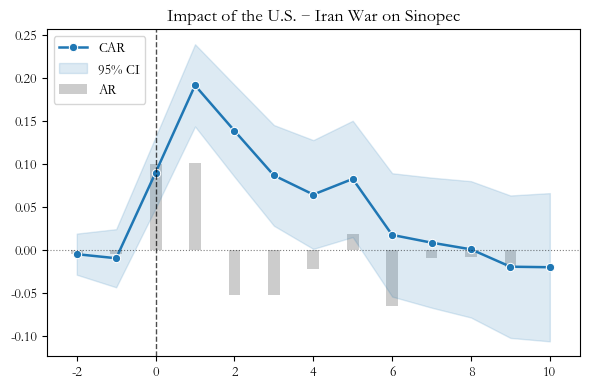

In [8]:
import pandas as pd
from event_study import  plot_company_event
e_id = 600028
e_date = '2026-02-28'
df_ar_by_company = pd.read_csv(r'output/tables/market_model_AR_by_company.csv')

plot_company_event(
    df_ar_by_company,
    figsize=(6,4),
    stockid=str(e_id),
    eventdate=pd.to_datetime(e_date, format='%Y-%m-%d'),  # 替换成实际事件日
    event_window='[-2,10]',
    title='Impact of the U.S.–Iran War on Sinopec',
    show_ci=True,
    save_path=rf'output\graphs\{e_id}_{e_date}.png',
    xlabel='',
    ylabel=''
)

Figure saved to: output\graphs\600938_2026-02-28.png


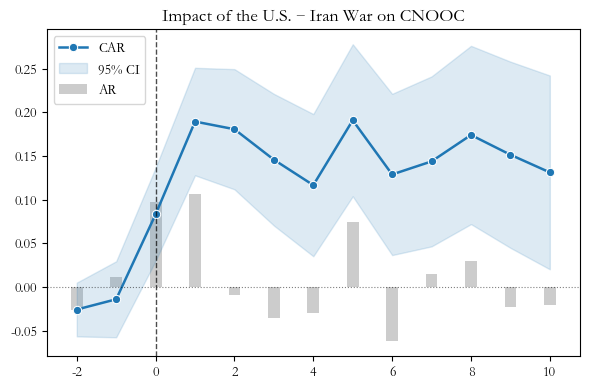

In [7]:
import pandas as pd
from event_study import  plot_company_event
e_id = 600938
e_date = '2026-02-28'
df_ar_by_company = pd.read_csv(r'output/tables/market_model_AR_by_company.csv')

plot_company_event(
    df_ar_by_company,
    figsize=(6,4),
    stockid=str(e_id),
    eventdate=pd.to_datetime(e_date, format='%Y-%m-%d'),  # 替换成实际事件日
    event_window='[-2,10]',
    title='Impact of the U.S.–Iran War on CNOOC',
    show_ci=True,
    save_path=rf'output\graphs\{e_id}_{e_date}.png',
    xlabel='',
    ylabel=''
)

## 不同公司之间的对比图

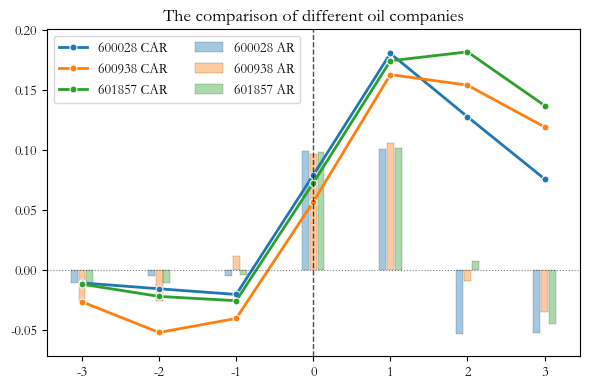

In [3]:
from scipy.stats import alpha
from event_study.event_plot import plot_company_comparison
import pandas as pd
import numpy as np
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import seaborn as sns
df_ar_by_company = pd.read_csv(r'output/tables/market_model_AR_by_company.csv')
fig = plot_company_comparison(
    df_ar_by_company=df_ar_by_company,
    figsize=(6,4),
    eventdate=pd.Timestamp('2026-02-28'),
    event_window_str='[-3,3]',
    title='The comparison of different oil companies',
    # colors=sns.color_palette('husl', 3),
    save_path=rf'output\graphs\comparison.png',
    xlabel='',
    ylabel=''
)

seaborn 常用调色板：

| 调色板        | 风格       | 颜色数量    | 
| ---------- | -------- | ------- | 
| Set2       | 柔和、浅色    | ≈8      | 
| husl       | 高对比、均匀色相 | 任意      | 
| muted      | 低饱和、克制   | ≈10     | 
| Paired     | 成对颜色     | ≈12（6对） | 
| deep       | 深色、标准    | ≈10     | 
| colorblind | 色盲友好     | ≈8      | 


## 基于所有公司与事件窗口的累计平均值

Figure saved to: output\graphs\ACAR.png


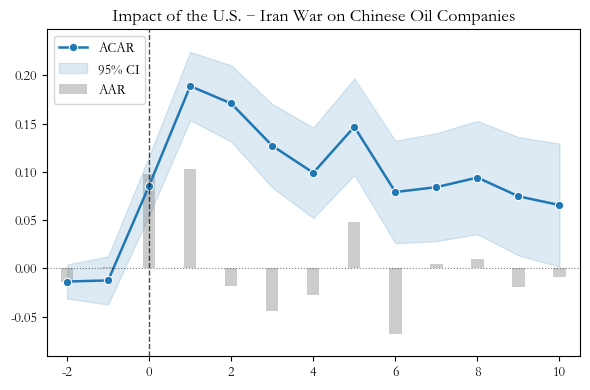

In [4]:
import pandas as pd
# 绘图 - 平均累计异常收益率 ACAR
df_aar = pd.read_csv(r'output/tables/market_model_AAR_daily.csv')
from event_study import plot_from_event_analysis
fig = plot_from_event_analysis(
    df_aar=df_aar,
    car_type='ACAR',
    figsize=(6,4),
    show_aar=True,        # 显示 AAR 柱状图
    event_window='[-2,10]',  # 指定窗口
    show_ci=True,         # 显示置信区间
    confidence=0.95,
    title='Impact of the U.S.–Iran War on Chinese Oil Companies',
    save_path=r'output\graphs\ACAR.png',
    xlabel='', #''意味着不传入横坐标
    ylabel=''
)

Figure saved to: output\graphs\CAAR.png


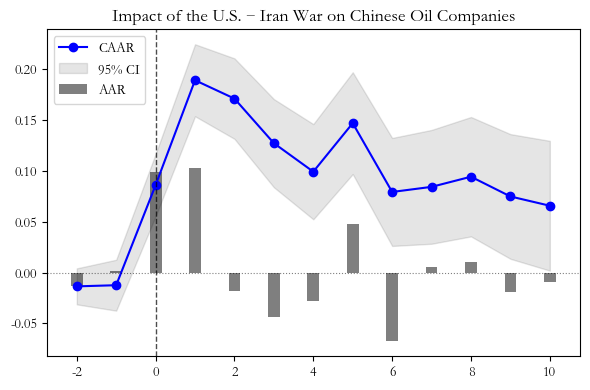

In [5]:
# 绘图 - 累计平均异常收益率 CAAR，实际上CAAR等于ACAR
# df_aar = pd.read_csv(r'output/tables/market_model_AAR_daily.csv')
from event_study.event_plot_copy import plot_from_event_analysis
fig = plot_from_event_analysis(
    df_aar=df_aar,
    figsize=(6,4),
    car_type='CAAR',
    show_aar=True,        # 显示 AAR 柱状图
    event_window='[-2,10]',  # 指定窗口
    show_ci=True,         # 显示置信区间
    confidence=0.95,
    title='Impact of the U.S.–Iran War on Chinese Oil Companies',
    save_path=r'output\graphs\CAAR.png'
)